# PENGWIN Dataset - Auditoría y Análisis Exploratorio de Entrada (EDA)
**Proyecto Integrador Corte 2 - Analítica de Datos**  
**Universidad Autónoma de Occidente (Semestre 2026-2)**

Este notebook ejecuta la auditoría de calidad de datos dentro de `02_auditoria`:
- Lectura de datos desde `01_data/` mediante búsqueda dinámica (`find_root`).
- Generación y almacenamiento de reportes CSV y figuras directamente en esta carpeta.

In [1]:
# Instalación de librerías necesarias
!pip install --quiet SimpleITK nibabel seaborn tqdm


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: C:\Users\USER\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import SimpleITK as sitk
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Configuración estética
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 10

# Localización dinámica de la raíz partiendo de 02_auditoria
def find_root(start: Path = None) -> Path:
    if start is None:
        start = Path.cwd()
    for p in [start, *start.parents]:
        if (p / "01_data" / "PENGWIN_CT_train_labels").is_dir():
            return p
    raise FileNotFoundError(f"No se encontró '01_data' desde {start}")

ROOT      = find_root()
DATA_DIR  = ROOT / "01_data"
AUDIT_DIR = ROOT / "02_auditoria"
AUDIT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Raíz del repositorio : {ROOT}")
print(f"Origen de datos      : {DATA_DIR}")
print(f"Carpeta de ejecución : {AUDIT_DIR}")

Raíz del repositorio : c:\Users\USER\OneDrive - Universidad Autonoma de Occidente\8 vo semestre\Analitica de datos\Proyecto\Corte 2\repositorio
Origen de datos      : c:\Users\USER\OneDrive - Universidad Autonoma de Occidente\8 vo semestre\Analitica de datos\Proyecto\Corte 2\repositorio\01_data
Carpeta de ejecución : c:\Users\USER\OneDrive - Universidad Autonoma de Occidente\8 vo semestre\Analitica de datos\Proyecto\Corte 2\repositorio\02_auditoria


In [3]:
# Indexación de imágenes y etiquetas
image_dirs = [
    DATA_DIR / "PENGWIN_CT_train_images_part1",
    DATA_DIR / "PENGWIN_CT_train_images_part2"
]
labels_dir = DATA_DIR / "PENGWIN_CT_train_labels"

images_dict = {}
labels_dict = {}

# 1. Indexar imágenes
for img_folder in image_dirs:
    if img_folder.exists():
        for f in img_folder.rglob("*.*"):
            if f.is_file() and f.suffix.lower() in [".mha", ".nii", ".gz"]:
                case_id = f.name.replace(".nii.gz", "").replace(".nii", "").replace(".mha", "")
                images_dict[case_id] = f

# 2. Indexar etiquetas
if labels_dir.exists():
    for f in labels_dir.rglob("*.*"):
        if f.is_file() and f.suffix.lower() in [".mha", ".nii", ".gz"]:
            case_id = f.name.replace(".nii.gz", "").replace(".nii", "").replace(".mha", "")
            labels_dict[case_id] = f

# 3. Casos coincidentes
common_cases = sorted(list(set(images_dict.keys()).intersection(set(labels_dict.keys()))))
print(f"Total imágenes encontradas : {len(images_dict)}")
print(f"Total máscaras encontradas : {len(labels_dict)}")
print(f"Casos emparejados listos   : {len(common_cases)}")

Total imágenes encontradas : 100
Total máscaras encontradas : 100
Casos emparejados listos   : 100


In [4]:
# Función de carga SimpleITK (formato Z, Y, X)
def load_sitk_volume(path):
    reader = sitk.ImageFileReader()
    reader.SetFileName(str(path))
    image = reader.Execute()
    data = sitk.GetArrayFromImage(image)
    dim_x, dim_y, dim_z = image.GetSize()
    dx, dy, dz = image.GetSpacing()
    return data, (dim_x, dim_y, dim_z), (dx, dy, dz)

print("Cargador SimpleITK configurado.")

Cargador SimpleITK configurado.


In [5]:
metadata_records = []
print(f"Extrayendo metadatos de {len(common_cases)} volúmenes...")
for case_id in tqdm(common_cases):
    img_data, (dim_x, dim_y, dim_z), (dx, dy, dz) = load_sitk_volume(images_dict[case_id])
    lbl_data, (ldim_x, ldim_y, ldim_z), _ = load_sitk_volume(labels_dict[case_id])
    
    lbl_data = lbl_data.astype(np.int16)
    unique_labels = np.unique(lbl_data)
    unique_labels = unique_labels[unique_labels > 0]
    
    sacrum_frags = [l for l in unique_labels if 1 <= l <= 10]
    left_hip_frags = [l for l in unique_labels if 11 <= l <= 20]
    right_hip_frags = [l for l in unique_labels if 21 <= l <= 30]
    anomalous = [l for l in unique_labels if l > 30]
    
    slices_with_bone = int(np.sum(np.any(lbl_data > 0, axis=(1, 2))))
    voxel_vol = dx * dy * dz
    bone_vol_cm3 = (int(np.sum(lbl_data > 0)) * voxel_vol) / 1000.0
    
    metadata_records.append({
        "case_id": case_id,
        "dim_x": dim_x, "dim_y": dim_y, "dim_z": dim_z,
        "dx_mm": round(dx, 4), "dy_mm": round(dy, 4), "dz_mm": round(dz, 4),
        "voxel_vol_mm3": round(voxel_vol, 4),
        "shape_match": (dim_x == ldim_x and dim_y == ldim_y and dim_z == ldim_z),
        "hu_min": round(float(np.min(img_data)), 1),
        "hu_max": round(float(np.max(img_data)), 1),
        "hu_mean": round(float(np.mean(img_data)), 1),
        "hu_p99": round(float(np.percentile(img_data, 99)), 1),
        "total_fragments": len(unique_labels),
        "n_sacrum_frags": len(sacrum_frags),
        "n_left_hip_frags": len(left_hip_frags),
        "n_right_hip_frags": len(right_hip_frags),
        "n_anomalous_labels": len(anomalous),
        "bone_volume_cm3": round(bone_vol_cm3, 2),
        "slices_with_bone": slices_with_bone,
        "bone_slice_ratio": round(slices_with_bone / dim_z, 4)
    })

df_eda = pd.DataFrame(metadata_records)
output_csv = AUDIT_DIR / "resumen_metadatos_pengwin.csv"
df_eda.to_csv(output_csv, index=False)
print(f"Archivo guardado en: {output_csv}")
df_eda.head()

Extrayendo metadatos de 100 volúmenes...


100%|██████████| 100/100 [03:47<00:00,  2.27s/it]

Archivo guardado en: c:\Users\USER\OneDrive - Universidad Autonoma de Occidente\8 vo semestre\Analitica de datos\Proyecto\Corte 2\repositorio\02_auditoria\resumen_metadatos_pengwin.csv


,case_id,dim_x,dim_y,dim_z,dx_mm,dy_mm,dz_mm,voxel_vol_mm3,shape_match,hu_min,...,hu_mean,hu_p99,total_fragments,n_sacrum_frags,n_left_hip_frags,n_right_hip_frags,n_anomalous_labels,bone_volume_cm3,slices_with_bone,bone_slice_ratio
0,001,512,512,401,0.7812,0.7812,0.8,0.4883,True,-1023.0,...,-501.8,507.0,4,1,2,1,0,1039.57,291,0.7257
1,002,413,276,337,0.8242,0.8242,0.8,0.5435,True,-1023.0,...,-307.5,593.0,6,2,1,3,0,744.80,258,0.7656
2,003,512,381,285,0.7598,0.7598,1.0,0.5772,True,-1023.0,...,-427.2,625.0,6,1,4,1,0,757.68,213,0.7474
3,004,386,254,224,0.8438,0.8438,1.0,0.7119,True,-1418.0,...,-187.2,698.0,6,2,2,2,0,598.89,183,0.8170
4,005,512,512,312,0.8965,0.8965,1.0,0.8037,True,-1023.0,...,-688.6,304.0,6,1,2,3,0,642.75,193,0.6186


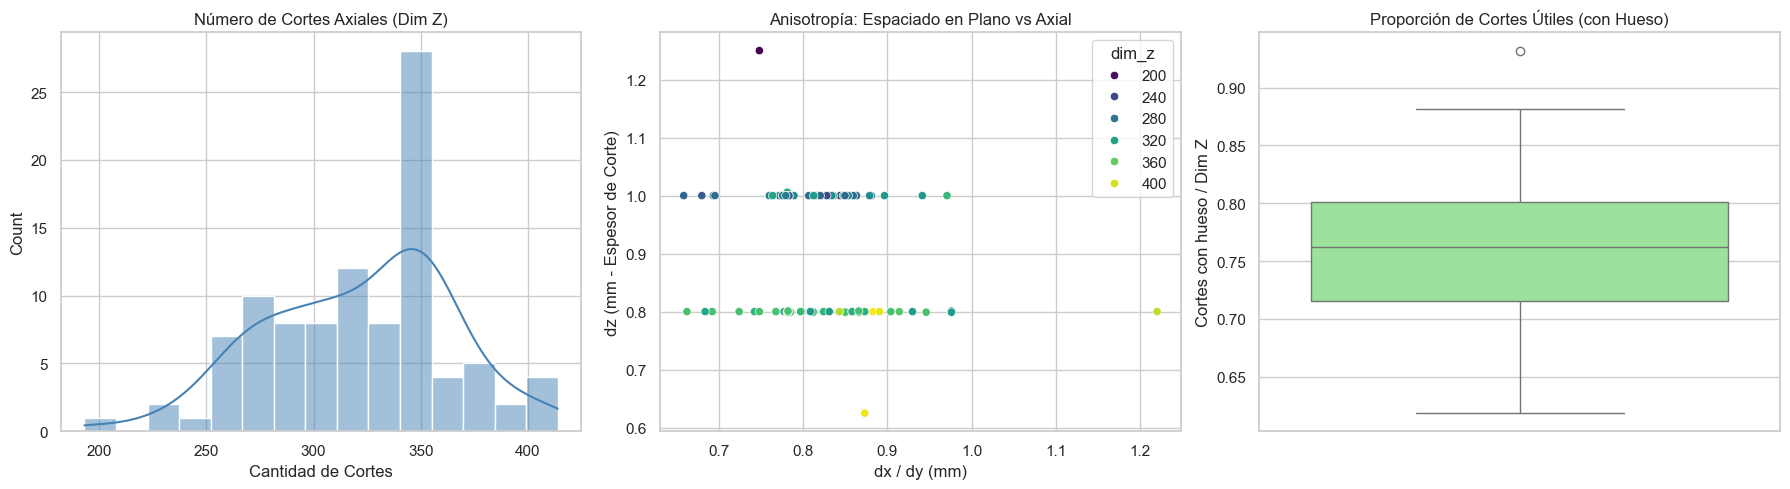

In [6]:
# Distribución espacial guardada en 02_auditoria
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df_eda["dim_z"], kde=True, ax=axes[0], color="steelblue", bins=15)
axes[0].set_title("Número de Cortes Axiales (Dim Z)")
axes[0].set_xlabel("Cantidad de Cortes")

sns.scatterplot(data=df_eda, x="dx_mm", y="dz_mm", hue="dim_z", palette="viridis", ax=axes[1])
axes[1].set_title("Anisotropía: Espaciado en Plano vs Axial")
axes[1].set_xlabel("dx / dy (mm)")
axes[1].set_ylabel("dz (mm - Espesor de Corte)")

sns.boxplot(y=df_eda["bone_slice_ratio"], ax=axes[2], color="lightgreen")
axes[2].set_title("Proporción de Cortes Útiles (con Hueso)")
axes[2].set_ylabel("Cortes con hueso / Dim Z")

plt.tight_layout()
plt.savefig(AUDIT_DIR / "distribucion_espacial.png", dpi=300)
plt.show()

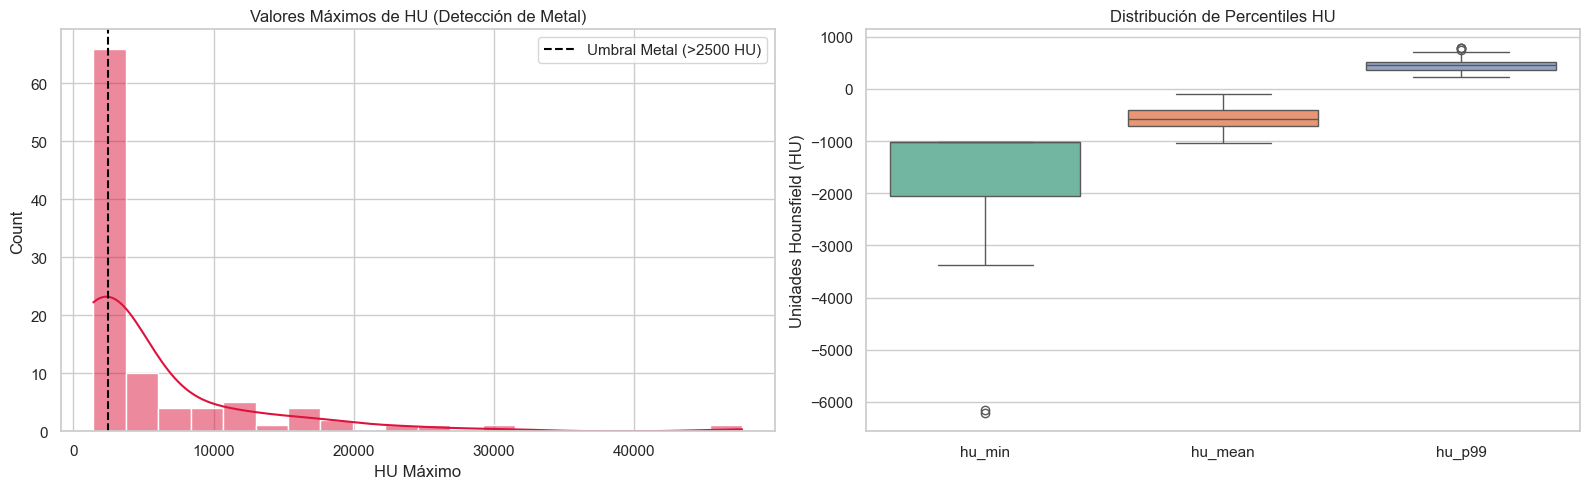

In [7]:
# Distribución de HU y detección de metal guardada en 02_auditoria
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(df_eda["hu_max"], kde=True, ax=axes[0], color="crimson", bins=20)
axes[0].axvline(2500, color="black", linestyle="--", label="Umbral Metal (>2500 HU)")
axes[0].set_title("Valores Máximos de HU (Detección de Metal)")
axes[0].set_xlabel("HU Máximo")
axes[0].legend()

sns.boxplot(data=df_eda[["hu_min", "hu_mean", "hu_p99"]], ax=axes[1], palette="Set2")
axes[1].set_title("Distribución de Percentiles HU")
axes[1].set_ylabel("Unidades Hounsfield (HU)")

plt.tight_layout()
plt.savefig(AUDIT_DIR / "distribucion_hu.png", dpi=300)
plt.show()

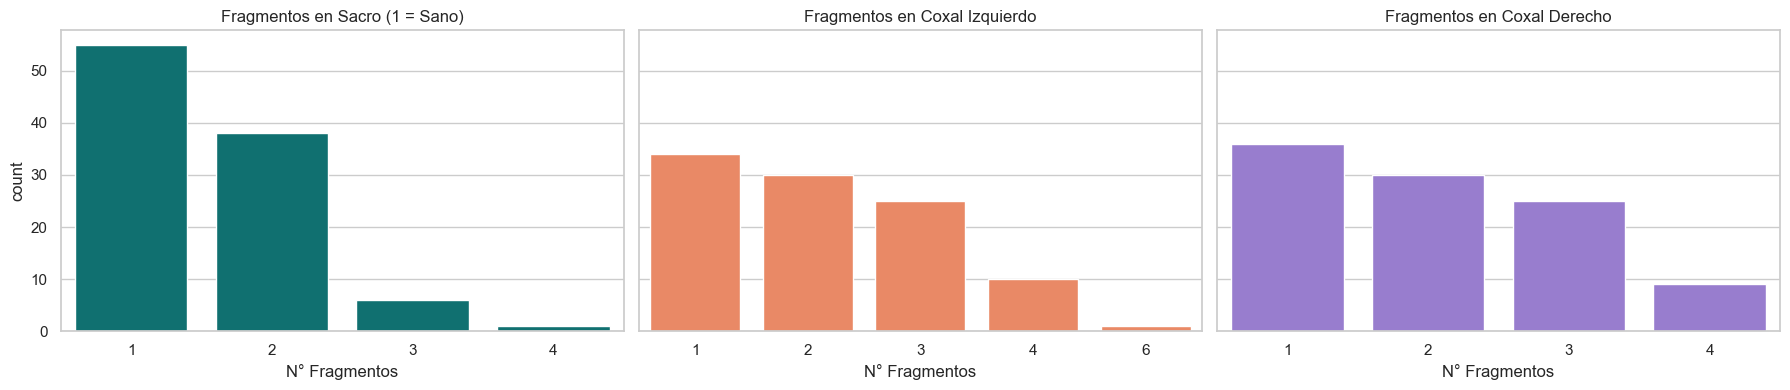

In [8]:
# Distribución de fragmentos guardada en 02_auditoria
df_eda['sacro_fracturado'] = df_eda['n_sacrum_frags'] > 1
df_eda['coxal_izq_fracturado'] = df_eda['n_left_hip_frags'] > 1
df_eda['coxal_der_fracturado'] = df_eda['n_right_hip_frags'] > 1

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)
sns.countplot(data=df_eda, x="n_sacrum_frags", ax=axes[0], color="teal")
axes[0].set_title("Fragmentos en Sacro (1 = Sano)")
axes[0].set_xlabel("N° Fragmentos")

sns.countplot(data=df_eda, x="n_left_hip_frags", ax=axes[1], color="coral")
axes[1].set_title("Fragmentos en Coxal Izquierdo")
axes[1].set_xlabel("N° Fragmentos")

sns.countplot(data=df_eda, x="n_right_hip_frags", ax=axes[2], color="mediumpurple")
axes[2].set_title("Fragmentos en Coxal Derecho")
axes[2].set_xlabel("N° Fragmentos")

plt.tight_layout()
plt.savefig(AUDIT_DIR / "distribucion_fragmentos.png", dpi=300)
plt.show()

In [9]:
# Consolidación de auditoría final guardada en 02_auditoria
auditoria = []
for _, r in df_eda.iterrows():
    alertas = []
    if not r['shape_match']:
        alertas.append('Dimensiones incompatibles')
    if r['n_anomalous_labels'] > 0:
        alertas.append(f'Etiquetas fuera de taxonomía ({r["n_anomalous_labels"]})')
    if r['hu_max'] > 2500:
        alertas.append(f'Artefacto metálico (HU máx {r["hu_max"]:.0f})')
    if r['bone_slice_ratio'] < 0.25:
        alertas.append(f'Baja cobertura ósea axial ({r["bone_slice_ratio"]*100:.1f}%)')
    if r['total_fragments'] == 0:
        alertas.append('Máscara vacía')
        
    estado = 'Atípico / Desafiante' if len(alertas) > 0 else 'Limpio / Confiable'
    auditoria.append({
        'case_id': r['case_id'],
        'estado': estado,
        'n_alertas': len(alertas),
        'observaciones': '; '.join(alertas) if alertas else 'Conforme'
    })

df_auditoria = pd.DataFrame(auditoria)
df_reporte = df_eda.merge(df_auditoria, on='case_id')
audit_csv = AUDIT_DIR / "auditoria_calidad_casos.csv"
df_reporte.to_csv(audit_csv, index=False)

print(f"Auditoría guardada exitosamente en: {audit_csv}")
print(df_reporte["estado"].value_counts())

Auditoría guardada exitosamente en: c:\Users\USER\OneDrive - Universidad Autonoma de Occidente\8 vo semestre\Analitica de datos\Proyecto\Corte 2\repositorio\02_auditoria\auditoria_calidad_casos.csv
estado
Limpio / Confiable      53
Atípico / Desafiante    47
Name: count, dtype: int64
